# Binomial Distribution Simulation

This code simulates a binomial distribution with $n=4$ trials and success probability $p=0.5$.  
It runs 1000 independent experiments, each consisting of 4 trials, and counts the frequency of getting 0, 1, 2, 3, or 4 successes.

Finally, it creates a bar plot to visualize the distribution of the number of successes.

---

### Theoretical Probability (Binomial Formula)

The probability of exactly $k$ successes in $n$ trials is given by the binomial probability mass function:

$$
P(X = k) = \binom{n}{k} p^k (1-p)^{n-k}
$$

where:
- $n = 4$ (number of trials)
- $p = 0.5$ (probability of success on each trial)
- $\binom{n}{k} = \dfrac{n!}{k!(n-k)!}$ is the binomial coefficient

**Example:** Probability of exactly 2 successes:

$$
P(X=2) = \binom{4}{2} (0.5)^2 (0.5)^{2} = 6 \times 0.0625 = 0.375
$$

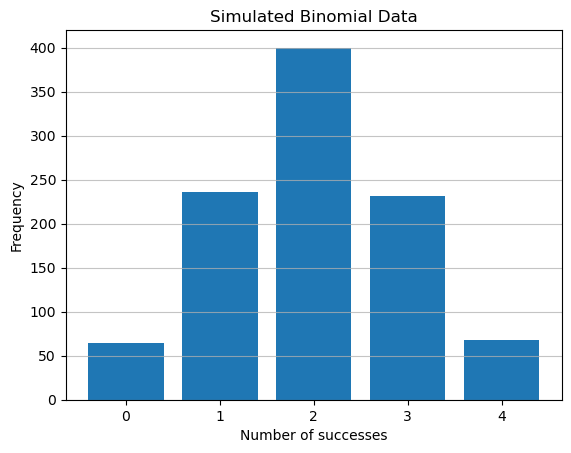

In [8]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(123)

trials=4
theta=0.5 #unknown value in a real experiment
data=np.random.binomial(trials, theta, 1000) #1000 simulated experiments
#Binomial distribution with 4 trials, probability of success 0.35, and 1000 samples.
plot_data=np.arange(trials+1) #This creates an array of integers from 0 to 4, which represents the possible number of successes in the binomial distribution with 4 trials.
plt.bar(plot_data, np.bincount(data)) # This creates a bar plot of the frequency of each number of successes (0 to 4) in the simulated data.
plt.xlabel('Number of successes')
plt.ylabel('Frequency')
plt.title('Simulated Binomial Data')
plt.xticks(plot_data)
plt.grid(axis='y', alpha=0.75)
plt.show() # This plots the histogram of the simulated binomial data. 

In [ ]:
!pip install pymc

In [ ]:

import pymc as pm
with pm.Model() as model:
    # Prior distribution for theta (the probability of success)
    theta_prior = pm.Beta('theta', alpha=1, beta=1)  # Uniform prior

    # Likelihood function based on the observed data
    likelihood = pm.Binomial('likelihood', n=trials, p=theta_prior, observed=data)

    # Inference: Sample from the posterior distribution
    trace = pm.sample(2000, tune=1000, return_inferencedata=False)